## CAT AND DOG CLASSIFICATON

Develop a deep learning model that can accurately classify images as either cats or dogs using labeled image data, enabling automated and efficient image recognition.

## import the file from the drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Zip path

In [2]:
zip_path = "/content/drive/MyDrive/Cats-Dogs-2.zip"

## Unlock zip file

In [3]:
import zipfile
with zipfile.ZipFile(zip_path, 'r')as zip_ref:
  zip_ref.extractall('/content/data')

##Set dataset path

In [4]:
data_dir='/content/dataset/PetImages'

## Importing Basic Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout, Dense

## Data preprocessing

In [6]:
data_dir = '/content/data/PetImages'
img_size = (224,224)
batch_size = (32)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    )

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

validation_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


#Build model

## Mobilenetv2

In [7]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model=models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Handling Corrupted Images

In [9]:
import os
from PIL import Image

def clean_dataset(data_dir):
    for category in ['Cat', 'Dog']:
        folder_path = os.path.join(data_dir, category)

        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)

            try:
                img = Image.open(file_path)
                img.verify()  # check if image is valid
            except:
                print("Removing corrupted file:", file_path)
                os.remove(file_path)

# Run cleaning
clean_dataset(data_dir)

Removing corrupted file: /content/data/PetImages/Cat/Thumbs.db
Removing corrupted file: /content/data/PetImages/Cat/666.jpg


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removing corrupted file: /content/data/PetImages/Dog/Thumbs.db
Removing corrupted file: /content/data/PetImages/Dog/11702.jpg


## insights
* Some files like Thumbs.db were present in both Cat and Dog folders
* These are system files, not images
* A few image files (e.g., 666.jpg, 11702.jpg) were found to be corrupted or unreadable
* The dataset contained corrupted and non-image files such as Thumbs.db and damaged JPEG images. These were identified and removed during preprocessing to ensure smooth training and improve model performance.

## Re-initialize ImageDataGenerator flow objects after cleaning and Train model

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Dropout, Dense

# Re-initialize ImageDataGenerator flow objects after cleaning
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    )

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

validation_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=validation_data
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1284s 2s/step - accuracy: 0.9673 - loss: 0.0852 - val_accuracy: 0.9790 - val_loss: 0.0556
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1277s 2s/step - accuracy: 0.9744 - loss: 0.0636 - val_accuracy: 0.9780 - val_loss: 0.0549
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1277s 2s/step - accuracy: 0.9780 - loss: 0.0557 - val_accuracy: 0.9774 - val_loss: 0.0594
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1300s 2s/step - accuracy: 0.9804 - loss: 0.0506 - val_accuracy: 0.9788 - val_loss: 0.0520
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1309s 2s/step - accuracy: 0.9807 - loss: 0.0497 - val_accuracy: 0.9776 - val_loss: 0.0567
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1265s 2s/step - accuracy: 0.9816 - loss: 0.0468 - val_accuracy: 0.9790 - val_loss: 0.0545
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1254s 2s/step - accuracy: 0.9827 - loss: 0.0450 - val_accuracy: 0.9798 - val_loss: 0.0541
Epoch

## Plot results

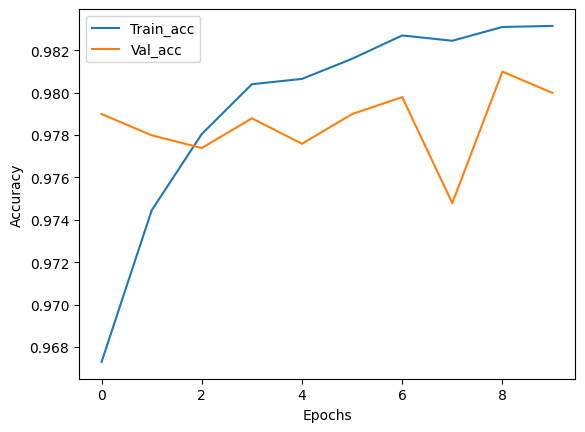

In [11]:
plt.plot(history.history['accuracy'], label='Train_acc')
plt.plot(history.history['val_accuracy'], label='Val_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Prediction function

In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(model, img_path):
  img = image.load_img(img_path, target_size=(224,224))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  prediction = model.predict(img_array)

  if prediction[0][0] > 0.5:
    print('Dog')
  else:
    print('cat')

## predicting the cat and dog

In [19]:
predict_image(model, "/content/data/PetImages/Cat/9.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
cat


In [20]:
predict_image(model, "/content/data/PetImages/Dog/7.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Dog


In [27]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/data/PetImages/Cat/7.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
print("Dog Probability:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Dog Probability: 5.58568e-06


In [25]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = "/content/data/PetImages/Dog/7.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
print("Dog Probability:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Dog Probability: 0.94306135


##Conclusion

The project shows how deep learning can be used to classify images as cats or dogs. Data cleaning was important to remove corrupted and invalid files, ensuring smooth training. Using data augmentation improved model performance and reduced overfitting. Transfer learning with MobileNetV2 helped achieve high accuracy while reducing training time. Overall, the model successfully learned to identify key features in images and demonstrates the effectiveness of CNNs in image classification tasks.